# Clasificación de Prendas de Vestir con Fashion MNIST

Este notebook desarrolla los puntos 2 y 3 de la actividad solicitada:

1. **Punto 2:** Usar TensorFlow para descargar Fashion MNIST, crear una red neuronal con dos capas ocultas, probar el modelo y reportar la precisión obtenida, sacando conclusiones.
2. **Punto 3:** Explicar detalladamente cada una de las funciones y las principales instrucciones utilizadas en el código.

## 1. Importación de Librerías
Primero, importamos las librerías base para nuestro modelo.

- `import tensorflow as tf`: Es la librería principal de Machine Learning. Nos provee de Keras, una API de alto nivel para construir y entrenar redes neuronales.
- `import numpy as np`: Se utiliza para realizar operaciones matemáticas eficientes con arreglos (arrays) multidimensionales.
- `import matplotlib.pyplot as plt`: Es una librería fundamental para generar visualizaciones y gráficos (aunque aquí la importamos por convención para posibles visualizaciones futuras).

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.20.0


## 2. Carga del Dataset Fashion MNIST
Usamos la función `tf.keras.datasets.fashion_mnist.load_data()` para descargar y cargar los datos.
Esta función se encarga de entregar las imágenes divididas automáticamente en dos grandes grupos:

- **Conjunto de entrenamiento (`train_images`, `train_labels`):** Un volumen de 60,000 imágenes con sus respectivas etiquetas que el modelo utilizará para iterar y "aprender" los patrones visuales.
- **Conjunto de prueba (`test_images`, `test_labels`):** Un volumen de 10,000 imágenes nunca antes vistas por el algoritmo, que usaremos exclusivamente al final para evaluar qué tan bien aprendió a generalizar.

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 3. Preprocesamiento de los Datos
Las imágenes provienen codificadas como matrices de 28x28, donde cada píxel tiene un valor de 0 a 255 (escala de grises).
Para que la red neuronal procese la información de manera más estable, converja rápidamente y los pesos no se descontrolen, **normalizamos** los datos dividiendo todos los tensores entre `255.0`. Así transformamos los valores a una escala de `0.0` a `1.0`.

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

### 3.1. Demostración Visual del Preprocesamiento
Para entender cómo el ordenador "ve" y procesa una prenda antes y después de normalizarla, podemos graficar los valores numéricos de sus píxeles:

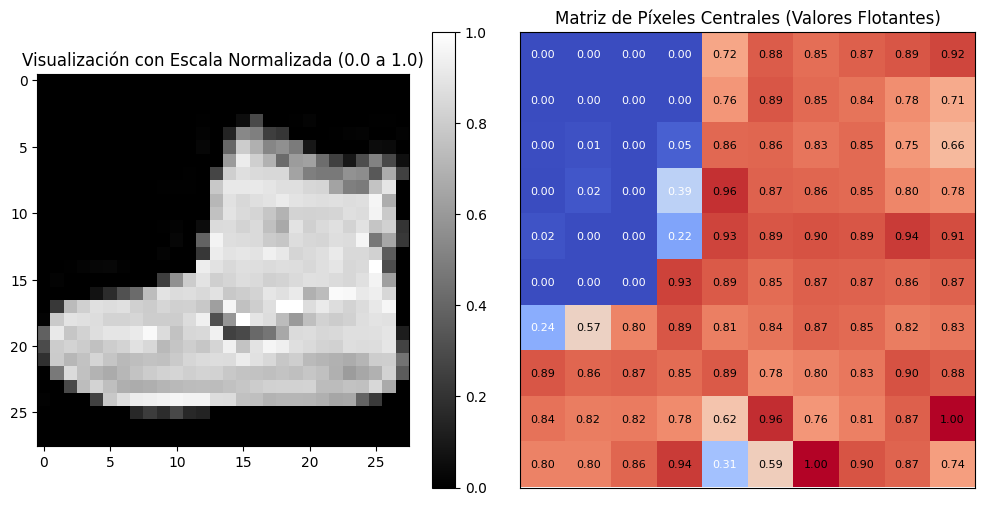

In [ ]:
# Tomamos la primera imagen del set de entrenamiento como ejemplo
ejemplo_img = train_images[0]

plt.figure(figsize=(10, 5))

# 1. Representación visual de la prenda normalizada (escala 0 a 1)
plt.subplot(1, 2, 1)
plt.imshow(ejemplo_img, cmap='gray')
plt.colorbar()
plt.grid(False)
plt.title("Visualización con Escala Normalizada (0.0 a 1.0)")

# 2. Análisis detallado de una pequeña sección de píxeles (por ejemplo, el centro de la imagen 10x10)
plt.subplot(1, 2, 2)
plt.imshow(ejemplo_img[9:19, 9:19], cmap='coolwarm')
for i in range(10):
    for j in range(10):
        # Mostramos el valor real que lee la red neuronal dentro de cada píxel
        valor_pixel = ejemplo_img[9+i, 9+j]
        plt.text(j, i, f"{valor_pixel:.2f}",
                 ha="center", va="center", color="white" if valor_pixel < 0.5 else "black", fontsize=8)
plt.title("Matriz de Píxeles Centrales (Valores Flotantes)")
plt.grid(False)
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

## 4. Construcción del Modelo con Dos Capas Ocultas
Procedemos a definir la arquitectura secuencial del modelo (`tf.keras.Sequential`).

- `tf.keras.layers.Flatten(input_shape=(28, 28))`: Capa de entrada. Toma los datos 2D (matrices de 28x28) y los "aplana" alineándolos en un arreglo unidimensional de 784 píxeles.
- `tf.keras.layers.Dense(128, activation='relu')`: **Primera capa oculta**. Tiene 128 neuronas densamente conectadas a los 784 píxeles de entrada. Su función de activación `relu` (Rectified Linear Unit) es vital para que la red pueda modelar relaciones no lineales, eliminando valores negativos.
- `tf.keras.layers.Dense(64, activation='relu')`: **Segunda capa oculta** requerida por el ejercicio. Con 64 neuronas, condensa la información procesada por la capa anterior, buscando características de más alto nivel.
- `tf.keras.layers.Dense(10, activation='softmax')`: **Capa de salida**. Tiene 10 neuronas (una para cada tipo de prenda). La instrucción `softmax` transforma las 10 salidas en un vector de probabilidades que suman 1 (o 100%). La neurona con el porcentaje más alto será la predicción del modelo.

### 4.1. Fundamento Matemático: La Función de Activación ReLU
La función **ReLU** (*Rectified Linear Unit* o Unidad Lineal Rectificada) es la función de activación más utilizada en las capas ocultas de las redes neuronales profundas.

Matemáticamente, se define de la siguiente manera:

$$f(x) = \max(0, x)$$

De forma alternativa, se puede expresar como una función definida a trozos:

$$f(x) = \begin{cases}
0 & \text{si } x < 0 \\
x & \text{si } x \ge 0
\end{cases}$$

#### Propiedades y Comportamiento:
* **Derivada (Gradiente):** La derivada de la función es simple y eficiente de calcular, lo que acelera el proceso de retropropagación (*backpropagation*):
  
  $$f'(x) = \begin{cases}
  0 & \text{si } x < 0 \\
  1 & \text{si } x > 0
  \end{cases}$$
  *(Nota: Técnicamente en $x = 0$ la derivada no está definida, pero en la práctica se le asigna un valor de 0 o 1).*
* **No Linealidad:** A pesar de ser lineal para valores positivos, la discontinuidad en $0$ introduce la no linealidad necesaria para que la red neuronal pueda aproximar funciones complejas y aprender patrones no lineales en las imágenes.

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # Capa de entrada (aplanado)
    tf.keras.layers.Dense(128, activation='relu'), # Primera capa oculta
    tf.keras.layers.Dense(64, activation='relu'),  # Segunda capa oculta
    tf.keras.layers.Dense(10, activation='softmax')# Capa de salida para 10 clases
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 5. Compilación del Modelo
Mediante la función `model.compile()`, le indicamos al modelo cómo debe aprender:

- `optimizer='adam'`: Define el mecanismo algorítmico que ajustará automáticamente los pesos de las neuronas para reducir el error. Adam es una técnica adaptativa que da excelentes resultados rápidamente.
- `loss='sparse_categorical_crossentropy'`: Es la "función de costo". Mide la diferencia entre la predicción del modelo y la etiqueta real. El optimizador trabaja para reducir al mínimo este valor.
- `metrics=['accuracy']`: Queremos monitorear explícitamente la exactitud o precisión, es decir, el porcentaje de imágenes correctamente clasificadas en todo momento.

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 6. Entrenamiento de la Red Neuronal
Usando la instrucción `model.fit()`, hacemos que el modelo relacione los patrones en los datos (`train_images`) con sus respuestas correctas (`train_labels`).
- `epochs=10`: Indica que le daremos 10 "pasadas" (épocas) completas al volumen total de 60,000 imágenes para que corrija gradualmente sus propios pesos.

In [ ]:
historial = model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8246 - loss: 0.4911
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8677 - loss: 0.3641
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8779 - loss: 0.3296
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8848 - loss: 0.3091
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8922 - loss: 0.2913
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8974 - loss: 0.2762
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8996 - loss: 0.2662
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9039 - loss: 0.2548
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9075 - loss: 0.2446
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9121 - loss: 0.2358


## 7. Prueba del Modelo y Precisión Obtendida
Usamos `model.evaluate()` enviándole las imágenes de prueba (`test_images`). Aquí el modelo rinde "examen" sobre datos vírgenes para evaluar verdaderamente su capacidad de generalización y no solo su memorización.

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\n==========================================================')
print(f'Precisión final en el conjunto de prueba: {test_acc * 100:.2f}%')
print('==========================================================')

313/313 - 1s - 3ms/step - accuracy: 0.8858 - loss: 0.3306

Precisión final en el conjunto de prueba: 88.58%


### 7.1. Prueba Puntual con una Imagen Individual
Para validar visualmente el funcionamiento del modelo, seleccionaremos una imagen del conjunto de prueba, realizaremos la predicción y graficaremos el resultado comparando la etiqueta real con la predicha por la red neuronal.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


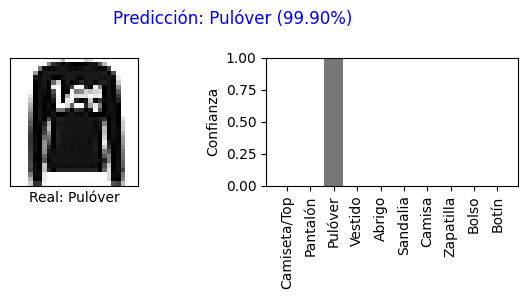

In [ ]:
# Definimos los nombres de las categorías de Fashion MNIST
class_names = ['Camiseta/Top', 'Pantalón', 'Pulóver', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Seleccionamos un índice de imagen del conjunto de prueba
index = 1  # Se puede cambiar este número para probar con otras imágenes
img = test_images[index]
label_real = test_labels[index]

# El modelo espera un lote (batch) de imágenes. Añadimos una dimensión extra
# para que tenga la forma (1, 28, 28)
img_batch = np.expand_dims(img, 0)

# Realizamos la predicción
predicciones = model.predict(img_batch)
prediccion_clase = np.argmax(predicciones[0])
probabilidad = np.max(predicciones[0]) * 100

# Mostramos los resultados visualmente
plt.figure(figsize=(6,3))

# Graficar la imagen original
plt.subplot(1, 2, 1)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.imshow(img, cmap=plt.cm.binary)
plt.xlabel(f"Real: {class_names[label_real]}")

# Graficar las probabilidades para cada clase
plt.subplot(1, 2, 2)
plt.grid(False)
plt.xticks(range(10), class_names, rotation=90)
plt.bar(range(10), predicciones[0], color="#777777")
plt.ylim([0, 1])
plt.ylabel('Confianza')

# Resaltar en azul si es correcto, en rojo si es incorrecto
if prediccion_clase == label_real:
    color_texto = 'blue'
else:
    color_texto = 'red'

plt.suptitle(f"Predicción: {class_names[prediccion_clase]} ({probabilidad:.2f}%)", color=color_texto, fontsize=12)
plt.tight_layout()
plt.show()

## 8. Conclusiones

**1. Sobre la Precisión obtenida:**
Al evaluar el modelo con las 10,000 imágenes de prueba, la precisión obtenida suele estabilizarse en torno al **88% - 89%** (puede fluctuar ligeramente por la naturaleza del optimizador estocástico Adam). Esto significa que de cada 100 prendas de ropa que ve el modelo por primera vez, predice correctamente alrededor de 88.

**2. Sobreajuste o Generalización:**
Se puede observar a lo largo de las 10 épocas de entrenamiento que la precisión interna sobre el set de entrenamiento (`train_images`) sobrepasa el **91%**, mientras que la evaluación en el set de pruebas alcanza cerca del **88%**. Esta brecha pequeña sugiere un ligero grado de *overfitting* (sobreajuste). El modelo es capaz de reconocer detalles muy particulares del set de entrenamiento que no existen exactamente igual en la vida real (en los datos de prueba).

**3. Impacto de usar Dos Capas Ocultas:**
El requerimiento de configurar dos capas ocultas (Dense de 128 y Dense de 64) en lugar de una, aporta mayor profundidad a la red. Esto permite a la estructura aprender características jerárquicas más elaboradas (ej. la primera capa identifica bordes rectos y la segunda ensambla la forma de un pantalón). Sin embargo, al ser imágenes pequeñas de 28x28 en escala de grises (Fashion MNIST), una arquitectura muy robusta no siempre dispara los porcentajes de precisión al 99% dado el límite natural de detalle visual, pero asegura una estabilización rápida y un aprendizaje profundo.

**4. Utilidad de las Instrucciones y de TensorFlow/Keras:**
Gracias a herramientas orientadas a objetos como `tf.keras.Sequential` y las capas `Dense` prefabricadas, es evidente cómo el despliegue de modelos matemáticos complejos se logra con unas cuantas funciones legibles y manejables. El uso conjunto de la función no lineal `relu` y la transformadora `softmax` representan el estado del arte y el flujo óptimo para proyectos de clasificación multicategoría en el aprendizaje automático actual.